In [5]:
# Imports and random seed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42

In [6]:
# Evaluation function
def evaluate(name, model):
    model.fit(X_tr, y_train)
    pred = model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae  = mean_absolute_error(y_val, pred)
    r2   = r2_score(y_val, pred)
    print(f'{name:22} RMSE={rmse:6.2f}  MAE={mae:6.2f}  R2={r2:6.3f}')
    return model

In [7]:
# Importing the data
df_train= pd.read_csv('../Train.csv')
df_train.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_O3_sensor_azimuth_angle,L3_O3_sensor_zenith_angle,L3_O3_solar_azimuth_angle,L3_O3_solar_zenith_angle,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_CO_sensor_azimuth_angle,L3_CO_sensor_zenith_angle,L3_CO_solar_azimuth_angle,L3_CO_solar_zenith_angle,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_sensor_azimuth_angle,L3_HCHO_sensor_zenith_angle,L3_HCHO_solar_azimuth_angle,L3_HCHO_solar_zenith_angle,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_sensor_azimuth_angle,L3_CLOUD_sensor_zenith_angle,L3_CLOUD_solar_azimuth_angle,L3_CLOUD_solar_zenith_angle,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_AER_AI_sensor_azimuth_angle,L3_AER_AI_sensor_zenith_angle,L3_AER_AI_solar_azimuth_angle,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,0.000156,-1.231330,0.006507,840209.874619,76.537512,38.634284,-61.736719,22.358167,0.000057,6156.074219,0.000017,0.119095,234.151102,0.000000,76.536426,38.593017,-61.752587,22.363665,0.021080,883.332451,267.017184,840138.461052,74.543393,38.622451,-61.789016,22.379054,-0.000010,0.000000,76.536426,38.593017,-61.752587,22.363665,0.000064,0.566828,NaN,NaN,0.000000,NaN,NaN,NaN,76.536426,38.593017,-61.752587,22.363665,NaN,-1.231330,840209.874619,76.537512,38.634284,-61.736719,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,0.000197,-1.082553,0.018360,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000055,6156.074219,0.000021,0.115179,233.313706,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.022017,1148.985447,61.216687,841116.763051,-57.015200,61.402626,-74.457583,33.089495,0.000114,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.000171,0.858446,175.019862,99354.162958,0.059358,5.958538,175.072145,99353.672374,-14.708036,59.624912,-67.693509,28.614804,0.315403,-1.082553,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,0

In [8]:
# Separation to train and val sets (what you sent me)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(df_train, groups=df_train['Place_ID']))

val_places = df_train.iloc[val_idx]['Place_ID'].unique()

place_split = df_train[['Place_ID']].drop_duplicates()
place_split['split'] = 'train'
place_split.loc[place_split['Place_ID'].isin(val_places), 'split'] = 'val'

place_split.to_csv('shared_place_split.csv', index=False)

place_split = pd.read_csv('shared_place_split.csv')
df = df_train.merge(place_split, on='Place_ID')

X_train = df[df.split == 'train'].drop(columns=['target', 'split'])
y_train = df[df.split == 'train']['target']
X_val   = df[df.split == 'val'].drop(columns=['target', 'split'])
y_val   = df[df.split == 'val']['target']

assert set(X_train['Place_ID']) & set(X_val['Place_ID']) == set()  # sanity check

print('X_train:', X_train.shape)
print('X_val:',X_val.shape)

X_train: (24546, 81)
X_val: (6011, 81)


In [9]:
# Separation to Weather dataset
weather_cols = [
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'specific_humidity_2m_above_ground',
    'temperature_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground',
]
X_weather = X_train[weather_cols].copy()
print(X_weather.shape)
X_weather.head()

(24546, 6)


,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground
0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395
1,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108
2,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559
3,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468
4,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559


In [10]:
# Weather data frame (with targets)
df_weather = pd.concat([X_weather, y_train], axis=1)
df_weather.head()

,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,target
0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,38.0
1,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,39.0
2,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,24.0
3,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,49.0
4,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,21.0


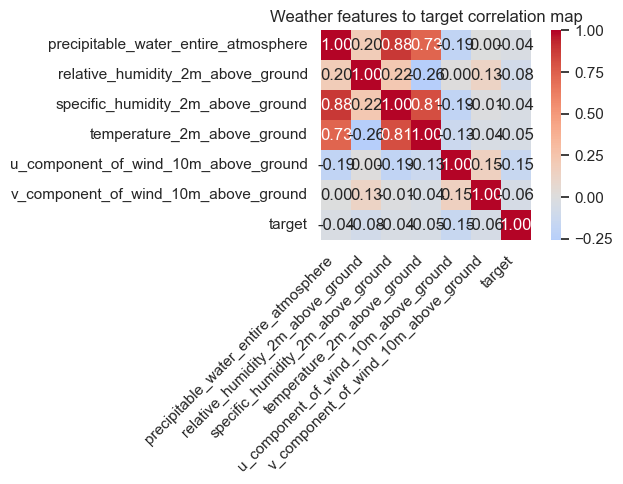

In [11]:
# Correlation heat map
plt.figure(figsize=(7, 5))
sns.heatmap(df_weather.corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Weather features to target correlation map')
plt.xticks(rotation=45, ha='right')  
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Removing specific humidity, due to high correlation with precipitable_water_entire_atmosphere (included in it)
df_weather= df_weather.drop(columns='specific_humidity_2m_above_ground')
df_weather.columns

Index(['precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground', 'target'],
      dtype='object')

<Axes: xlabel='wind_speed', ylabel='target'>

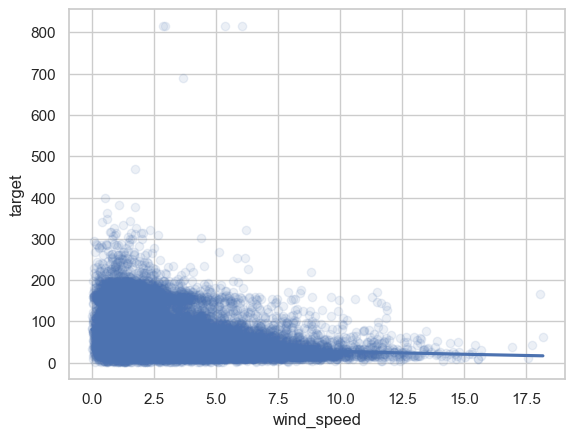

In [13]:
# Feature engineering of wind
u = df_weather['u_component_of_wind_10m_above_ground']
v = df_weather['v_component_of_wind_10m_above_ground']

# Calculating wind speed and direction (angle)
df_weather['wind_speed']     = np.sqrt(u**2 + v**2)
df_weather['wind_direction'] = (np.degrees(np.arctan2(v, u)) + 360) % 360   # 0–360°
rad = np.radians(df_weather['wind_direction'])
df_weather['wind_dir_sin'] = np.sin(rad)
df_weather['wind_dir_cos'] = np.cos(rad)
# Why sin and cos: Wind direction is circular (0° = 360°), so we encode it as sin and cos 
# to remove the false jump at the wrap-around and let the model see that directions like 359° 
# and 1° are actually close.

# Wind speed and target corelation:
sns.regplot(x='wind_speed', y='target', data=df_weather, lowess=True, scatter_kws={'alpha':0.1})

In [14]:
df_weather.head()

,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,target,wind_speed,wind_direction,wind_dir_sin,wind_dir_cos
0,11.000000,60.200001,18.516840,1.996377,-1.227395,38.0,2.343506,328.416332,-0.523743,0.851876
1,14.600000,48.799999,22.546533,3.330430,-1.188108,39.0,3.536009,340.366491,-0.336002,0.941861
2,16.400000,33.400002,27.031030,5.065727,3.500559,24.0,6.157557,34.645557,0.568498,0.822685
3,6.911948,21.300001,23.971857,3.004001,1.099468,49.0,3.198883,20.102680,0.343704,0.939078
4,13.900001,44.700001,16.816309,2.621787,2.670559,21.0,3.742413,45.527997,0.713593,0.700561
